# 04 · ANALYZE — Q1: precio Bangkok ↔ desempeño financiero
Tres lentes: (A) correlaciones, (B) panel con efectos fijos de empresa y errores Driscoll-Kraay, (C) empresa representativa (agregados ponderados por ingresos) con errores HAC.

In [1]:
import sys, warnings, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)
from IPython.display import Image, display
from src.analysis import correr_todo
R = correr_todo()
q1 = R['q1']

In [2]:
display(q1['corr'])

,tipo,metrica,n_empresa_anio,r_pearson,p_pearson,r_spearman,p_spearman,n_anios,r_agregado,p_agregado,direccion
0,Manufacturera,margen_bruto,403,0.0480,0.3367,0.0444,0.3742,15,0.0058,0.9837,↑ positiva
1,Manufacturera,margen_operativo,422,-0.0338,0.4883,0.0481,0.3246,15,0.5317,0.0413,↑ positiva
2,Manufacturera,margen_neto,422,-0.0524,0.2829,0.0434,0.3743,15,0.5765,0.0245,↑ positiva
3,Manufacturera,roa,422,-0.0217,0.6563,0.0331,0.4979,15,0.6471,0.0091,↑ positiva
4,Manufacturera,roe,405,0.0201,0.6869,0.0507,0.3084,15,0.6431,0.0097,↑ positiva
5,Pesquera,margen_bruto,1120,0.0867,0.0037,0.0641,0.0320,15,0.4659,0.0801,↑ positiva
6,Pesquera,margen_operativo,1270,0.1040,0.0002,0.1299,0.0000,15,0.8417,0.0001,↑ positiva
7,Pesquera,margen_neto,1270,0.0932,0.0009,0.1340,0.0000,15,0.8499,0.0001,↑ positiva
8,Pesquera,roa,1270,0.0420,0.1349,0.1170,0.0000,15,0.8344,0.0001,↑ positiva
9,Pesquera,roe,1223,0.0778,0.0065,0.1138,0.0001,15,0.8138,0.0002,↑ positiva


In [3]:
p = q1['panel']
display(p[p.variable=='precio_prom_100'].round(3))
print('Efecto de la VARIACIÓN anual del precio (+10%):')
display(p[p.variable=='dp10'].round(3))

,tipo,metrica,variable,coef_pp,ic95_inf_pp,ic95_sup_pp,p_value,n_obs,n_empresas,r2_within
0,Manufacturera,margen_bruto,precio_prom_100,0.596,-0.144,1.337,0.114,381,51,0.015
2,Manufacturera,margen_operativo,precio_prom_100,-0.025,-0.267,0.216,0.838,400,53,0.005
4,Manufacturera,margen_neto,precio_prom_100,-0.103,-0.333,0.126,0.377,400,53,0.006
6,Manufacturera,roa,precio_prom_100,0.088,-0.353,0.529,0.695,400,53,0.008
8,Manufacturera,roe,precio_prom_100,1.136,-0.624,2.896,0.205,384,52,0.014
10,Pesquera,margen_bruto,precio_prom_100,0.802,0.455,1.149,0.000,1075,165,0.011
12,Pesquera,margen_operativo,precio_prom_100,0.651,0.192,1.110,0.006,1222,177,0.014
14,Pesquera,margen_neto,precio_prom_100,0.436,0.216,0.656,0.000,1222,177,0.010
16,Pesquera,roa,precio_prom_100,0.137,-0.238,0.511,0.474,1222,177,0.001
18,Pesquera,roe,precio_prom_100,1.180,-0.568,2.929,0.186,1178,171,0.009


Efecto de la VARIACIÓN anual del precio (+10%):


,tipo,metrica,variable,coef_pp,ic95_inf_pp,ic95_sup_pp,p_value,n_obs,n_empresas,r2_within
1,Manufacturera,margen_bruto,dp10,-0.661,-1.198,-0.124,0.016,381,51,0.015
3,Manufacturera,margen_operativo,dp10,-0.326,-1.006,0.354,0.346,400,53,0.005
5,Manufacturera,margen_neto,dp10,-0.240,-0.829,0.349,0.424,400,53,0.006
7,Manufacturera,roa,dp10,-0.714,-2.063,0.636,0.299,400,53,0.008
9,Manufacturera,roe,dp10,-1.646,-4.693,1.400,0.289,384,52,0.014
11,Pesquera,margen_bruto,dp10,-0.254,-0.708,0.200,0.273,1075,165,0.011
13,Pesquera,margen_operativo,dp10,-0.165,-0.874,0.544,0.648,1222,177,0.014
15,Pesquera,margen_neto,dp10,0.122,-0.263,0.507,0.535,1222,177,0.010
17,Pesquera,roa,dp10,0.080,-0.680,0.841,0.836,1222,177,0.001
19,Pesquera,roe,dp10,-0.332,-2.727,2.064,0.786,1178,171,0.009


In [4]:
display(q1['agr'].round(3))
print('Test de asimetría (panel, margen operativo):', {k: round(v,4) for k,v in q1['asimetria'].items()})

,tipo,metrica,modelo,variable,coef_pp,ic95_inf_pp,ic95_sup_pp,p_value,r2,n_anios
0,Manufacturera,margen_bruto,nivel+variación,p100,0.118,-0.238,0.475,0.515,0.129,14
1,Manufacturera,margen_bruto,nivel+variación,dp10,-0.386,-0.812,0.040,0.076,0.129,14
2,Manufacturera,margen_bruto,solo nivel,p100,0.004,-0.328,0.335,0.983,0.000,15
3,Manufacturera,margen_operativo,nivel+variación,p100,0.410,0.165,0.654,0.001,0.450,14
4,Manufacturera,margen_operativo,nivel+variación,dp10,-0.398,-0.652,-0.144,0.002,0.450,14
5,Manufacturera,margen_operativo,solo nivel,p100,0.288,0.050,0.526,0.018,0.283,15
6,Manufacturera,margen_neto,nivel+variación,p100,0.317,0.150,0.484,0.000,0.483,14
7,Manufacturera,margen_neto,nivel+variación,dp10,-0.281,-0.460,-0.102,0.002,0.483,14
8,Manufacturera,margen_neto,solo nivel,p100,0.233,0.067,0.398,0.006,0.332,15
9,Manufacturera,roa,nivel+variación,p100,0.605,0.321,0.890,0.000,0.587,14


Test de asimetría (panel, margen operativo): {'coef_precio_manuf_pp': np.float64(-0.1043), 'coef_diferencial_pesquera_pp': np.float64(0.731), 'p_diferencial': np.float64(0.0)}


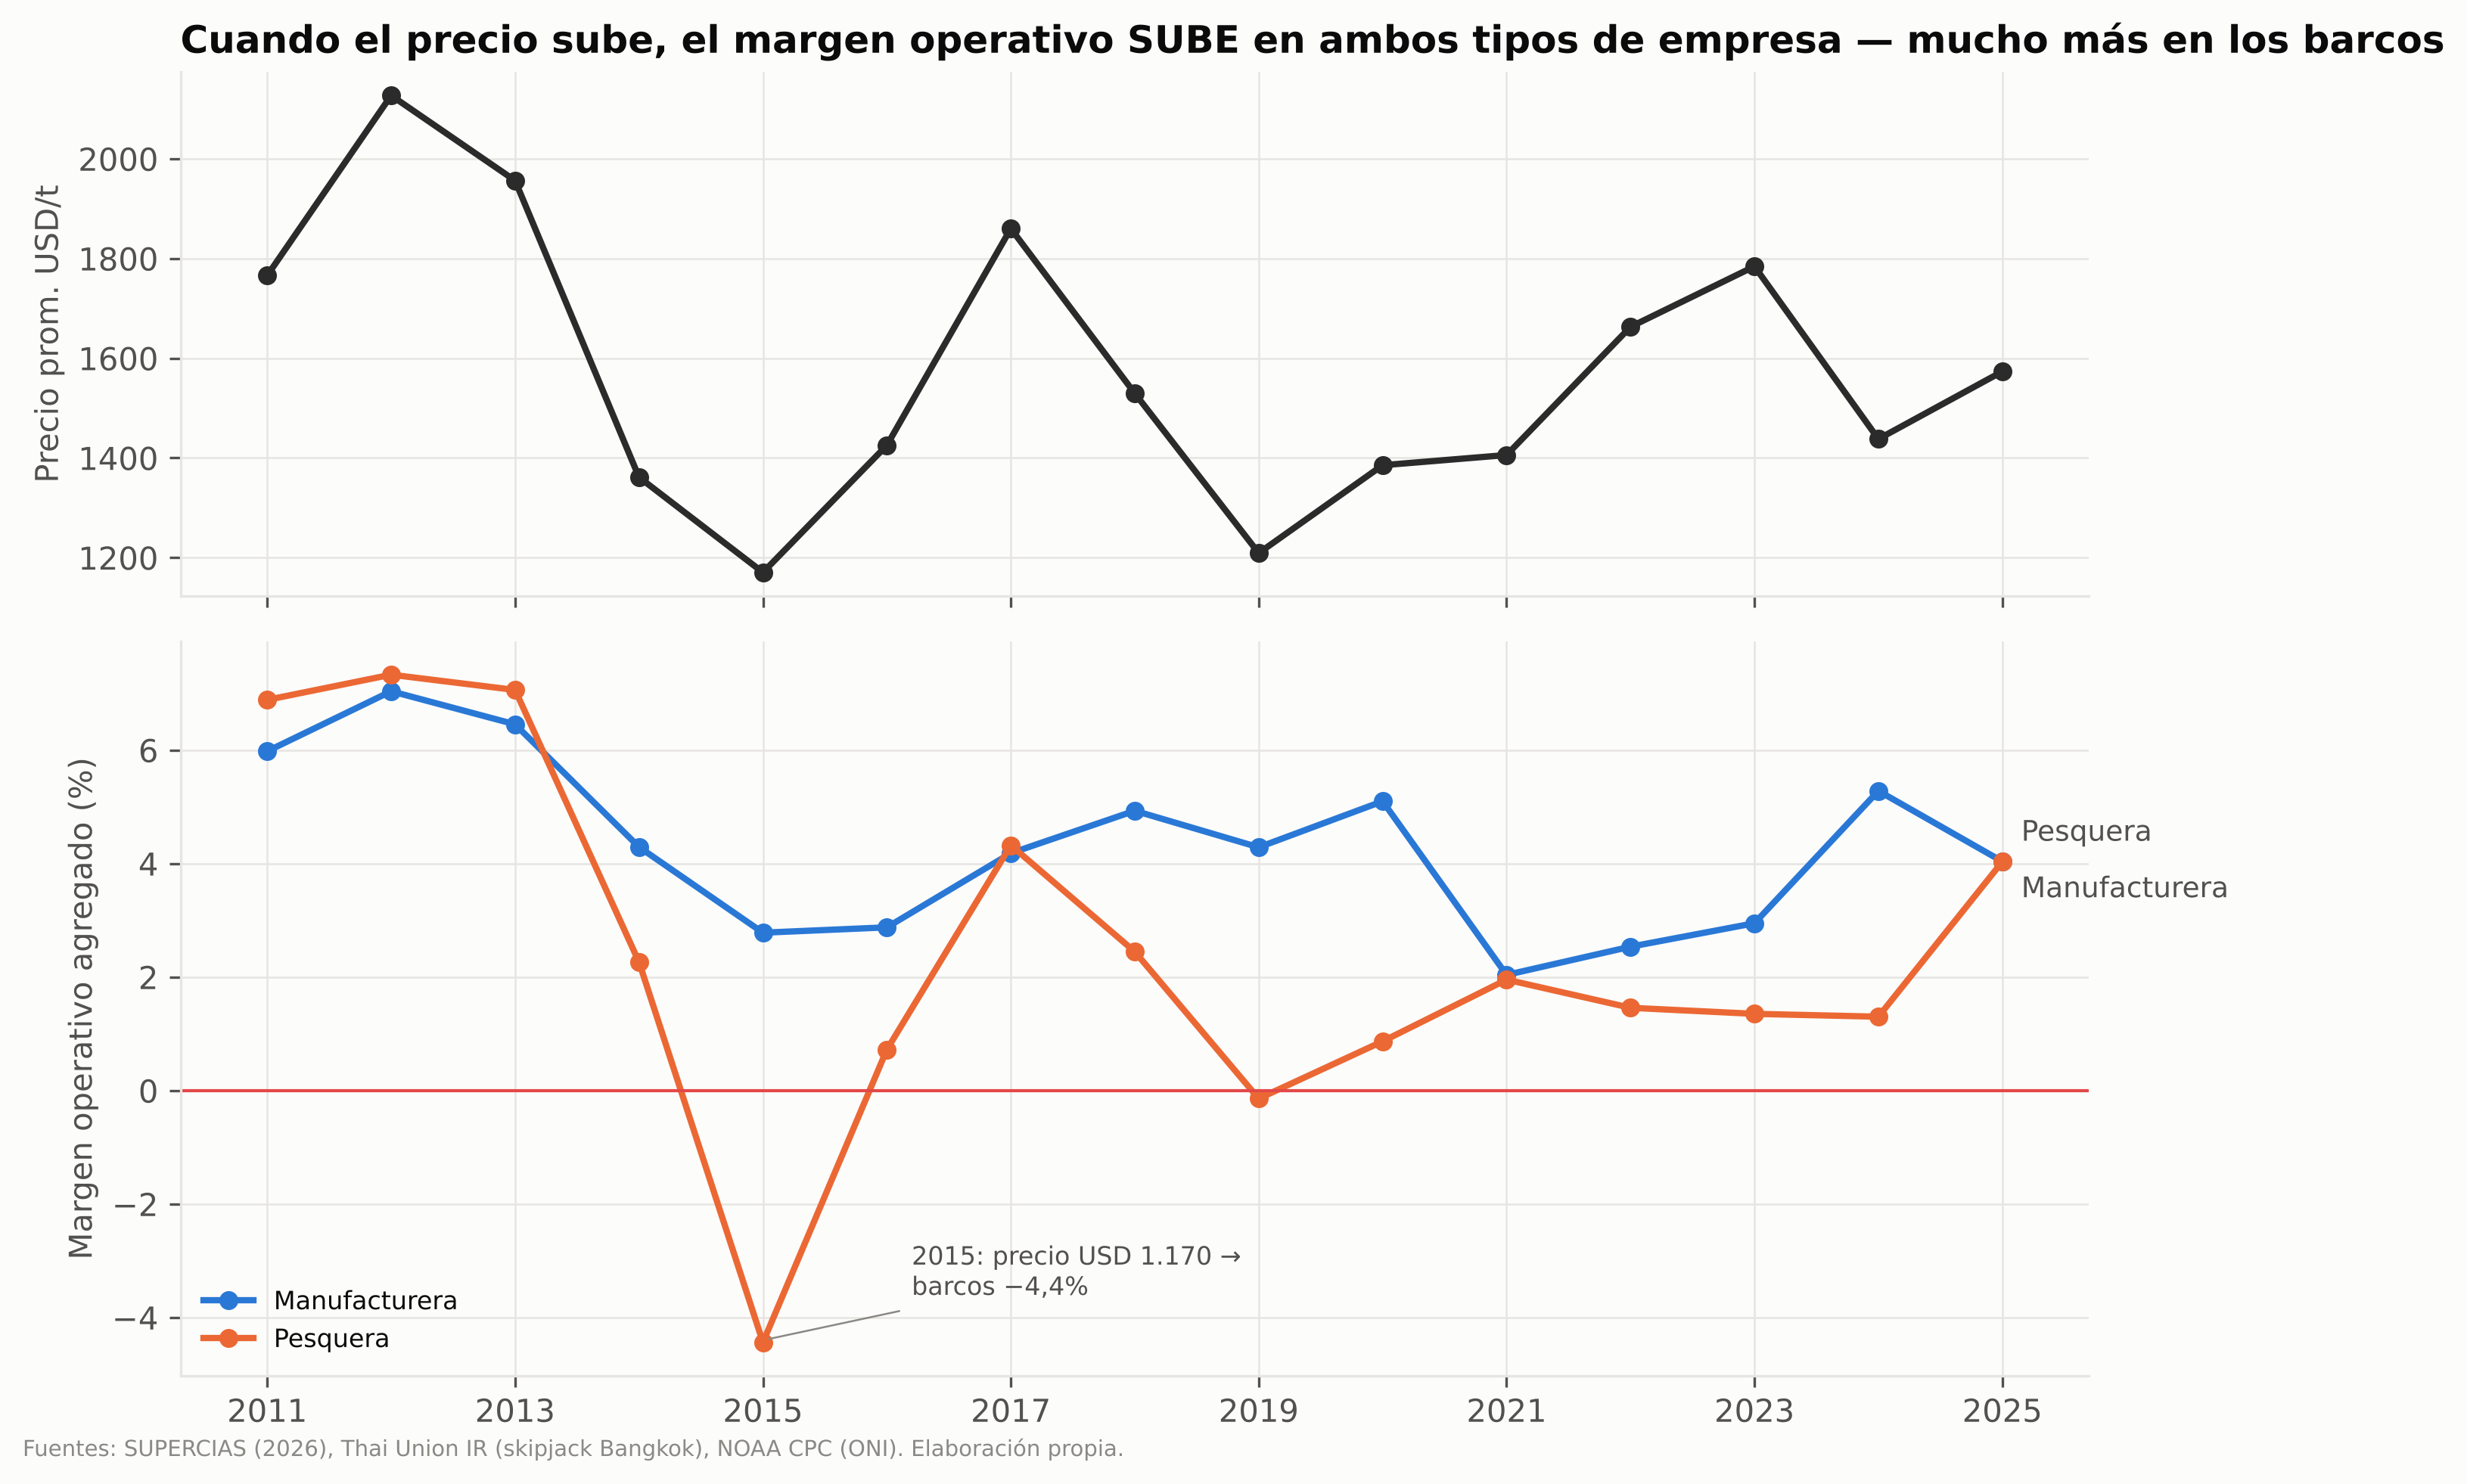

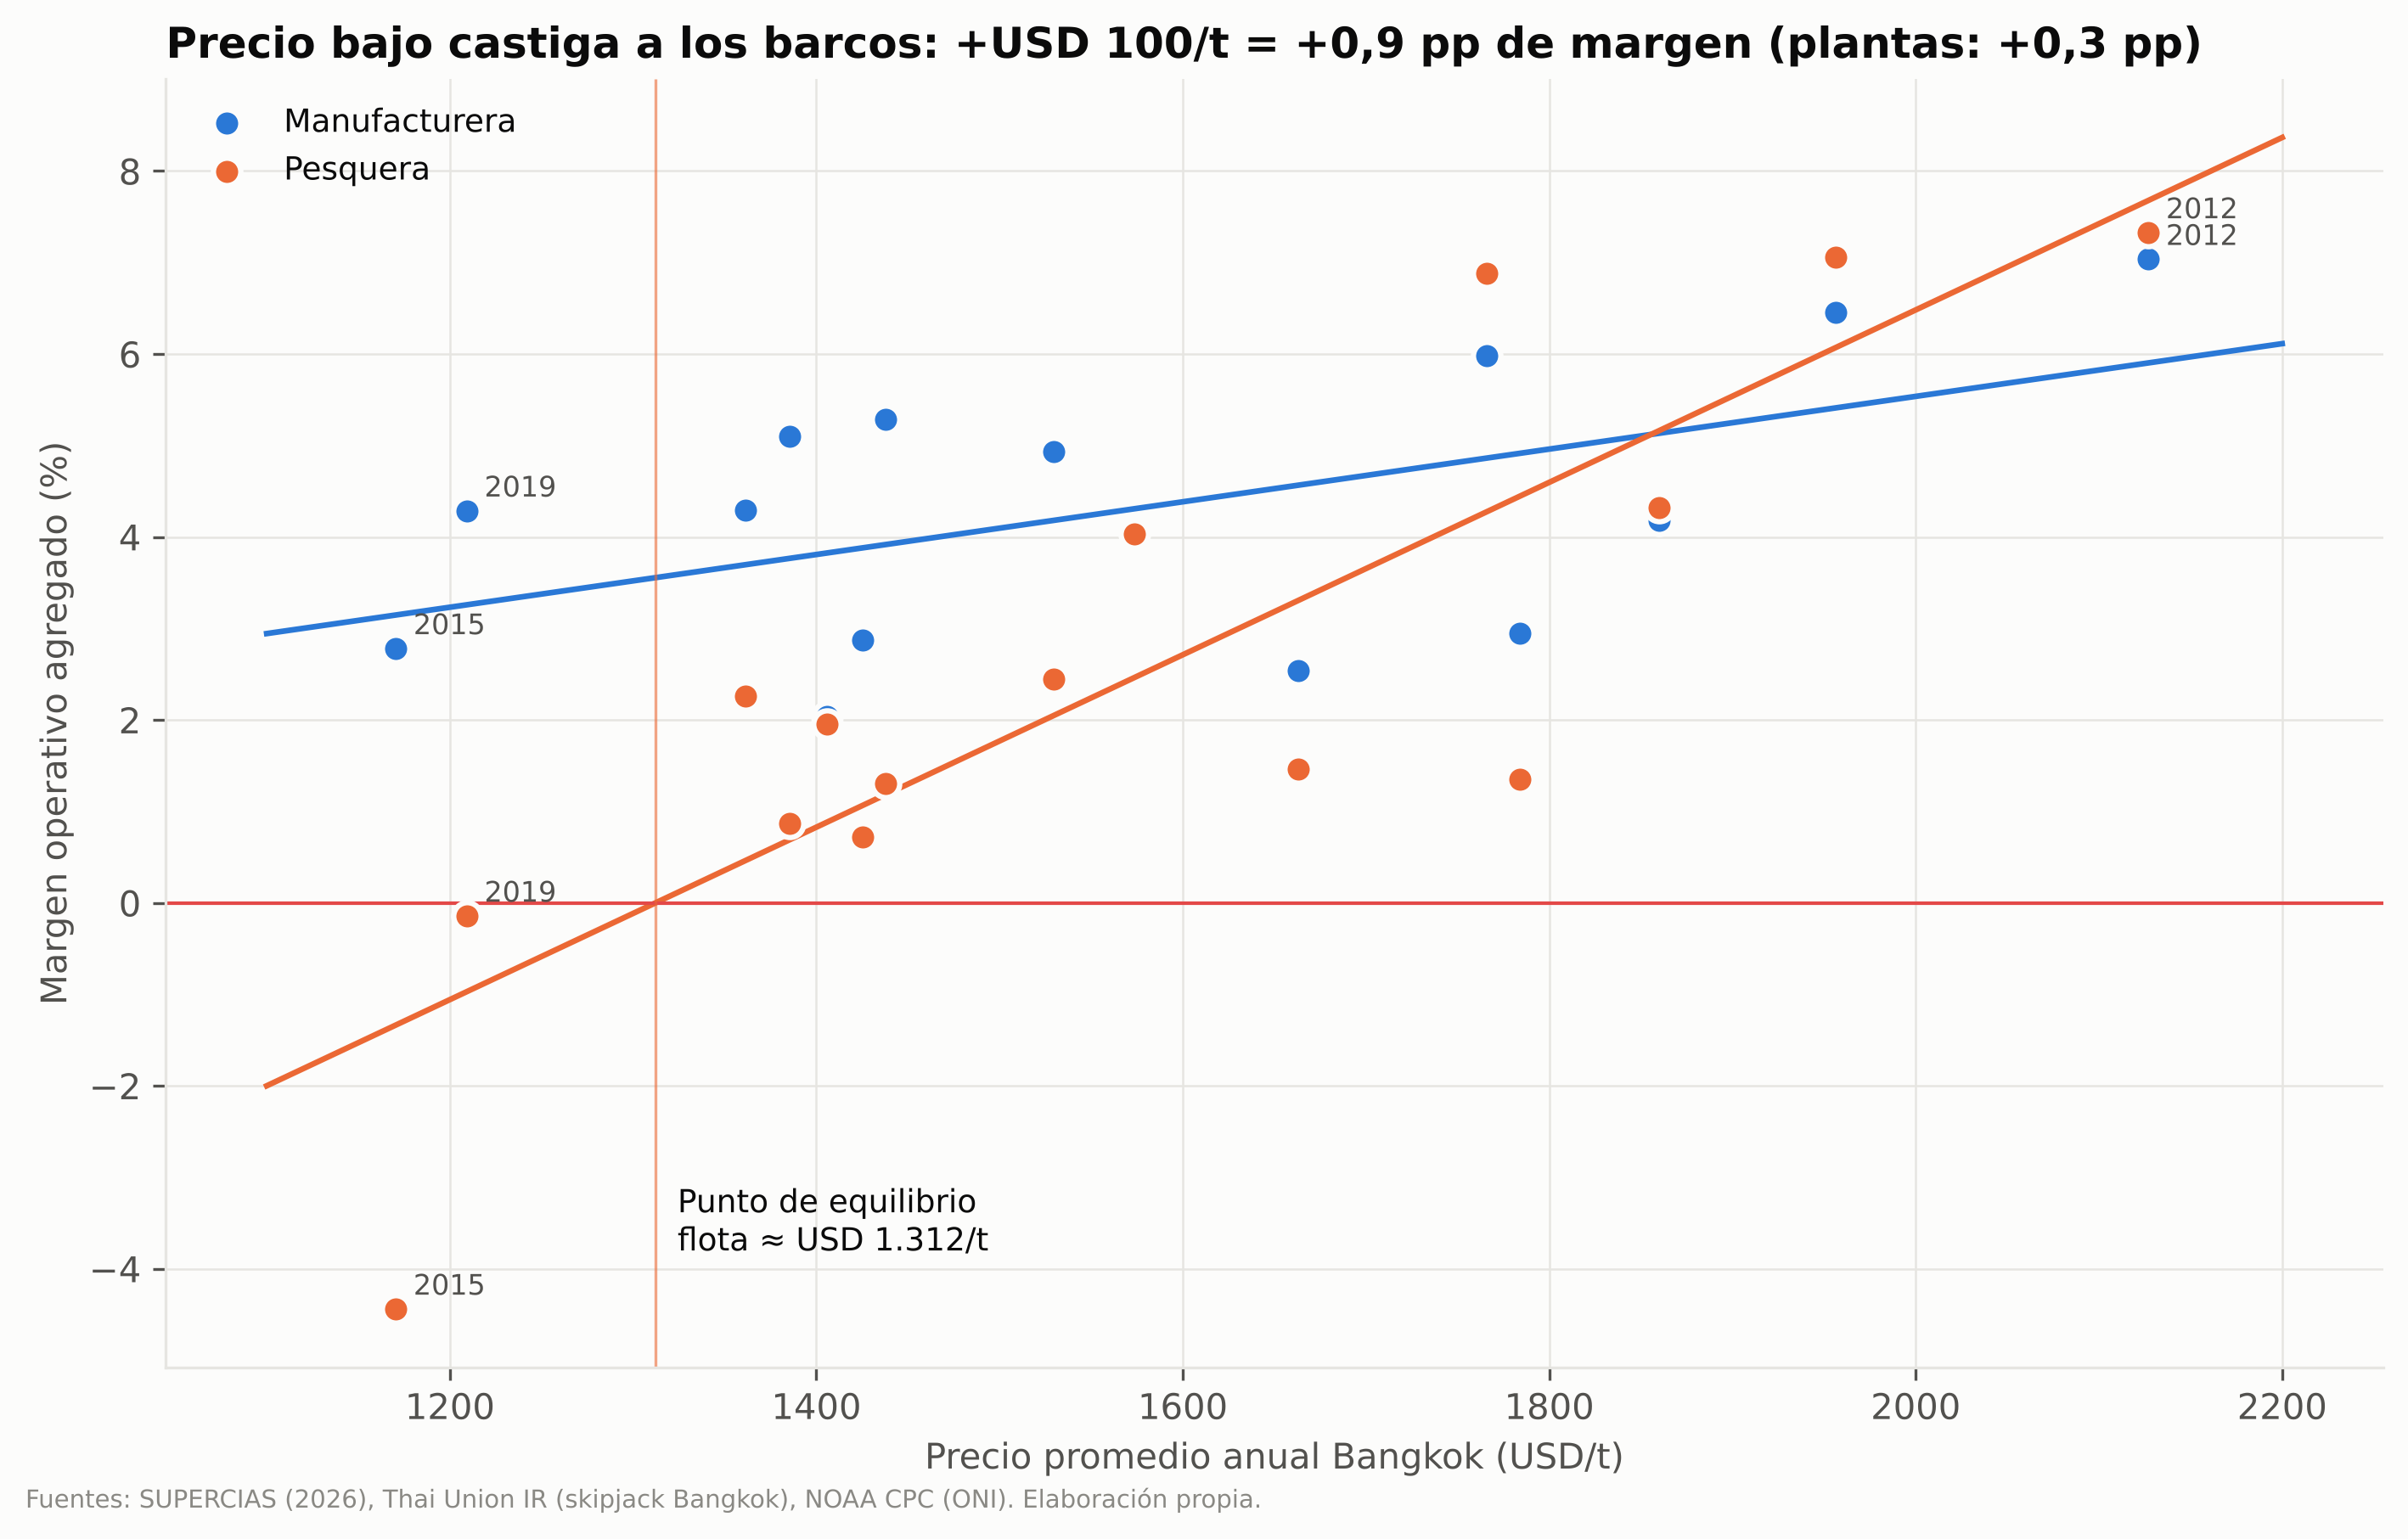

In [5]:
display(Image('../outputs/figures/fig2_precio_vs_margen_operativo.png', width=900))
display(Image('../outputs/figures/fig3_scatter_precio_margen_por_tipo.png', width=900))

### Lectura
- **H1b (pesqueras) — CONFIRMADA y fuerte.** Margen operativo agregado ≈ +0,94 pp por cada +USD 100/t (R² ≈ 0,71). Las ventas crecen ≈ +4,9% por cada +10% de precio.
- **H1a (manufactureras) — RECHAZADA en niveles.** El margen de las plantas **no cae** cuando el precio es alto (+0,29 pp por USD 100, p≈0,02 agregado; no significativo a nivel empresa): el costo se traslada al precio de la conserva/lomo.
- **Pero sí hay un efecto de VELOCIDAD:** a nivel empresa, cada +10% de **alza anual** del precio reduce el margen bruto de las plantas ≈ 0,66 pp (p≈0,016). El daño es transitorio: ocurre el año del salto, mientras los contratos de venta se reajustan.
- La diferencia de sensibilidad entre tipos es significativa (interacción tipo×precio, p<0,001).